<a href="https://colab.research.google.com/github/paulocarvalhoprcf/dataset-tcc/blob/main/TCC_Univesp_Previs%C3%B5es_para_o_CPI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import classification_report, accuracy_score
from sklearn.svm import SVC, SVR
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr, spearmanr
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.regularizers import l2
import torch
import torch.nn as nn

In [ ]:
dados = pd.read_csv('dataset.csv')
dados['Data'] = pd.to_datetime(dados['Data'])
dados.set_index('Data', inplace=True)
dados.head()

,BRL/USD,S&P500,XAU/USD,Crude,CPI,IBOV,IPCA
Data,,,,,,,
1994-07-01,0.9625,446.2,386.95,17.57,148.4,3581,148.4
1994-07-04,0.9350,446.2,386.95,17.47,148.4,3623,148.4
1994-07-05,0.9250,446.4,386.05,17.38,148.4,3581,148.4
1994-07-06,0.9100,446.1,383.95,17.06,148.4,3564,148.4
1994-07-07,0.9080,448.4,384.65,17.08,148.4,3754,148.4


In [ ]:
# Selecionar os conjuntos de dados com base nas variáveis qualificadas como significativas pelo Teste de Granger
# Com base no DataFrame com as variáveis S&P500, ouro, e Ibovespa
X = dados[['S&P500', 'XAU/USD', 'IBOV']]  # Variáveis independentes
y = dados['CPI']  # Variável dependente (CPI)

# Dividindo em treino e teste
X_train, X_test, y_train, y_test_lr = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Modelo de Regressão Linear
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Prevendo valores de CPI
y_pred_lr = lr_model.predict(X_test)

# Avaliando o desempenho com RMSE
rmse_lr = np.sqrt(mean_squared_error(y_test_lr, y_pred_lr))
print(f'RMSE da Regressão Linear: {rmse_lr}')

RMSE da Regressão Linear: 10.506200319622902


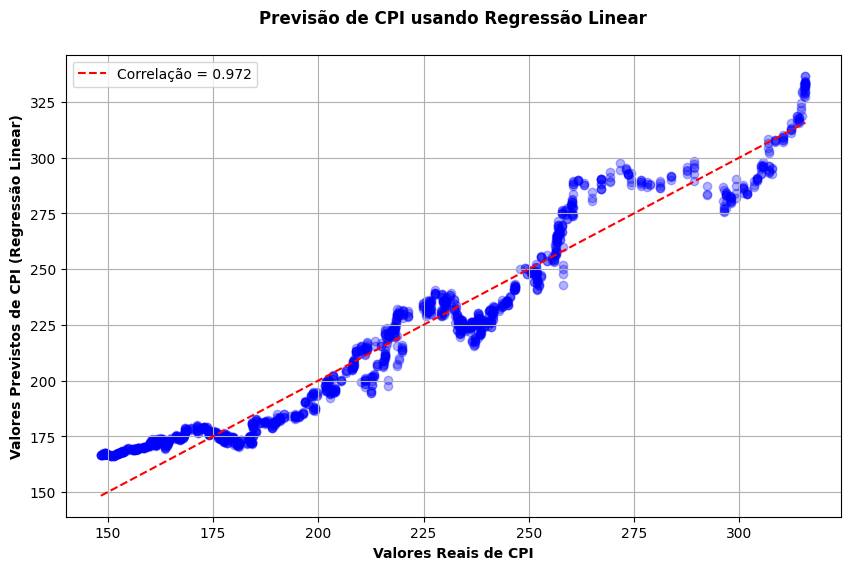

In [ ]:
# Plotando resultados
plt.figure(figsize=(10, 6))
plt.scatter(y_test_lr, y_pred_lr, color='blue', alpha=0.3)
plt.plot([min(y_test_lr), max(y_test_lr)], [min(y_test_lr), max(y_test_lr)], 'r--', label=f'Correlação = {np.round(np.corrcoef(y_test_lr, y_pred_lr)[0,1], 3)}')
plt.xlabel('Valores Reais de CPI', fontdict={'fontsize': 10}, weight='bold')
plt.ylabel('Valores Previstos de CPI (Regressão Linear)', fontdict={'fontsize': 10}, weight='bold')
plt.title('Previsão de CPI usando Regressão Linear', weight='bold', y=1.05)
plt.grid(True)
plt.legend()
plt.savefig('cpi_lr.png')
plt.show()

In [ ]:
# Selecionar os conjuntos de dados com base nas variáveis qualificadas como significativas pelo Teste de Granger
# Com base no DataFrame com as variáveis S&P500, ouro, e Ibovespa
X = dados[['S&P500', 'XAU/USD', 'IBOV']]  # Variáveis independentes
y = dados['CPI']  # Variável dependente (CPI)

# Dividindo em treino e teste
X_train, X_test, y_train, y_test_svm = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Normalizar os dados usando StandardScaler para melhorar o desempenho do modelo SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Crie uma instância do modelo SVR com os parâmetros desejados (kernel, C, epsilon)
# kernels: linear, polinomial, RBF
# Treine o modelo usando os dados de treinamento
model = SVR(kernel='rbf', C=100, epsilon=0.1)
model.fit(X_train, y_train)

SVR(C=100)

In [ ]:
# Fazer previsões usando os dados de teste
y_pred_svm = model.predict(X_test)

# Avaliando o desempenho com RMSE
rmse_svm = np.sqrt(mean_squared_error(y_test_svm, y_pred_svm))
print(f'RMSE do Support Vector Machine: {rmse_svm}')

RMSE do Support Vector Machine: 7.892235437884165


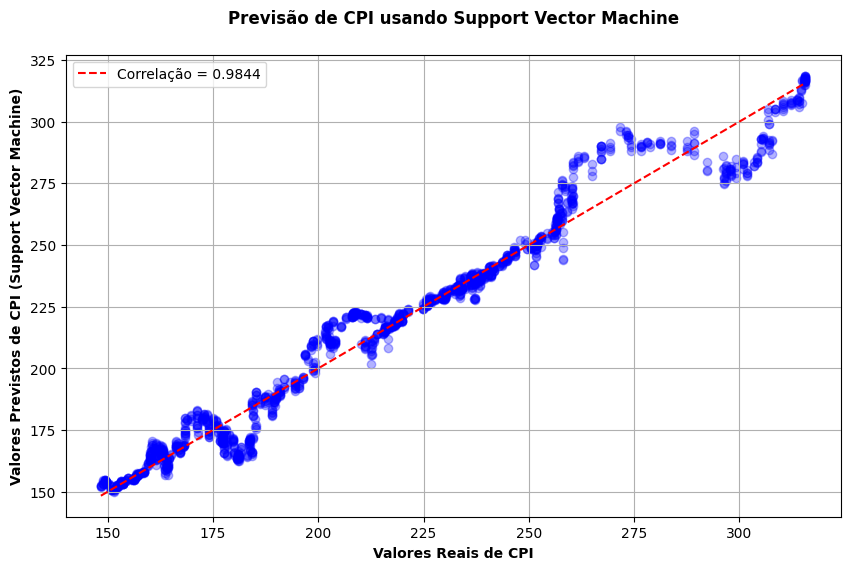

In [ ]:
# Plotando resultados
plt.figure(figsize=(10, 6))
plt.scatter(y_test_svm, y_pred_svm, color='blue', alpha=0.3)
plt.plot([min(y_test_svm), max(y_test_svm)], [min(y_test_svm), max(y_test_svm)], 'r--', label=f'Correlação = {np.round(np.corrcoef(y_test_svm, y_pred_svm)[0,1], 4)}')
plt.xlabel('Valores Reais de CPI', fontdict={'fontsize': 10}, weight='bold')
plt.ylabel('Valores Previstos de CPI (Support Vector Machine)', fontdict={'fontsize': 10}, weight='bold')
plt.title('Previsão de CPI usando Support Vector Machine', weight='bold', y=1.05)
plt.grid(True)
plt.legend()
plt.savefig('cpi_svm.png')
plt.show()

In [ ]:
# Selecionar os conjuntos de dados com base nas variáveis qualificadas como significativas pelo Teste de Granger
# Com base no DataFrame com as variáveis S&P500, ouro, e Ibovespa
X = dados[['S&P500', 'XAU/USD', 'IBOV']]  # Variáveis independentes
y = dados['CPI']  # Variável dependente (CPI)

# Dividindo em treino e teste
X_train, X_test, y_train, y_test_rf = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Modelo de Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Prevendo valores de CPI
y_pred_rf = rf_model.predict(X_test)

# Avaliando o desempenho com RMSE
rmse_rf = np.sqrt(mean_squared_error(y_test_rf, y_pred_rf))
print(f'RMSE do Random Forest: {rmse_rf}')

RMSE do Random Forest: 2.4572628460827546


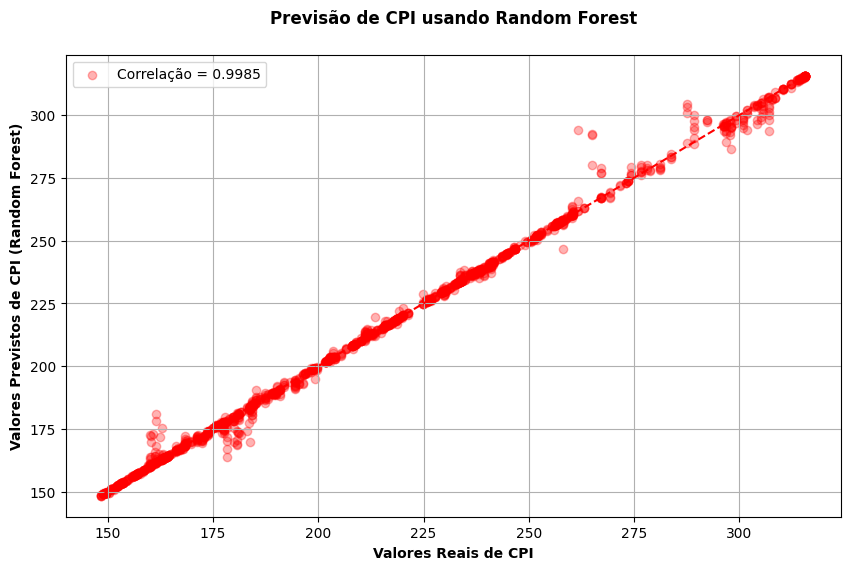

In [ ]:
# Plotando resultados
plt.figure(figsize=(10, 6))
plt.scatter(y_test_rf, y_pred_rf, color='red', alpha=0.3, label=f'Correlação = {np.round(np.corrcoef(y_test_rf, y_pred_rf)[0,1], 4)}')
plt.plot([min(y_test_rf), max(y_test_rf)], [min(y_test_rf), max(y_test_rf)], 'r--')
plt.xlabel('Valores Reais de CPI', fontdict={'fontsize': 10}, weight='bold')
plt.ylabel('Valores Previstos de CPI (Random Forest)', fontdict={'fontsize': 10}, weight='bold')
plt.title('Previsão de CPI usando Random Forest', weight='bold', y=1.05)
plt.grid(True)
plt.legend()
plt.savefig('cpi_rf.png')
plt.show()

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Padronizando os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividindo os dados em treino e teste
X_train, X_test, y_train, y_test_mlp = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Construindo a Rede Neural (MLP)
mlp_model = Sequential()
mlp_model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
# mlp_model.add(Dropout(0.1))  # Dropout de 10%
# mlp_model.add(Dense(64, activation='relu'))
# mlp_model.add(Dropout(0.1))  # Dropout de 10%
mlp_model.add(Dense(32, activation='relu'))
# mlp_model.add(Dropout(0.1))  # Dropout de 10%
mlp_model.add(Dense(16, activation='relu'))
mlp_model.add(Dense(1))  # Uma saída, já que estamos prevendo um único valor (CPI)

# Compilando o modelo
mlp_model.compile(optimizer='adam', loss='mean_squared_error')

# Treinando a rede neural
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
mlp_model.fit(X_train, y_train, epochs=500, batch_size=32, validation_data=(X_test, y_test_mlp), callbacks=[early_stop])

# Fazendo previsões
y_pred_mlp = mlp_model.predict(X_test).flatten()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/500
199/199 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 44133.0156 - val_loss: 6351.6982
Epoch 2/500
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 4400.6309 - val_loss: 906.2636
Epoch 3/500
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 698.1523 - val_loss: 315.4632
Epoch 4/500
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 272.3911 - val_loss: 171.7206
Epoch 5/500
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 157.0657 - val_loss: 116.2694
Epoch 6/500
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 107.9748 - val_loss: 89.5892
Epoch 7/500
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 87.3199 - val_loss: 77.5283
Epoch 8/500
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 76.5950 - val_loss: 72.4570
Epoch 9/500
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 70.5038 - val_loss: 68.8425
Epoch 10/500
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 67.8265 - val_loss: 71.9308
Epoch 11/500
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 67.1393 - val_loss: 64.2050
Epo

In [ ]:
# Avaliando o desempenho com RMSE
rmse_mlp = np.sqrt(mean_squared_error(y_test_mlp, y_pred_mlp))
print(f'RMSE da Rede Neural: {rmse_mlp}')

RMSE da Rede Neural: 5.32244689905048


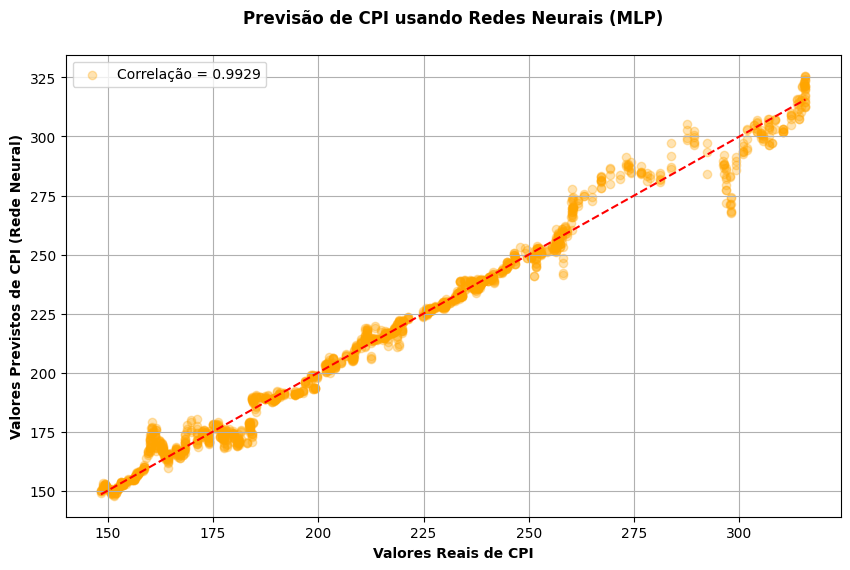

In [ ]:
# Plotando os resultados

plt.figure(figsize=(10, 6))
plt.scatter(y_test_mlp, y_pred_mlp, color='orange', alpha=0.3, label=f'Correlação = {np.round(np.corrcoef(y_test_mlp, y_pred_mlp)[0,1], 4)}')
plt.plot([min(y_test_mlp), max(y_test_mlp)], [min(y_test_mlp), max(y_test_mlp)], 'r--')

plt.xlabel('Valores Reais de CPI', fontdict={'fontsize': 10}, weight='bold')
plt.ylabel('Valores Previstos de CPI (Rede Neural)', fontdict={'fontsize': 10}, weight='bold')
plt.title('Previsão de CPI usando Redes Neurais (MLP)', weight='bold', y=1.05)
plt.grid(True)
plt.legend()
plt.savefig('cpi_mlp.png')
plt.show()

In [ ]:
# Carregando os dados
# Supondo que você já tenha um DataFrame chamado df com os dados
# df = p# Selecionar as colunas de interesse
features = dados[['S&P500', 'XAU/USD', 'IBOV']]  # Variáveis independentes
target = dados['CPI']  # Variável dependente (CPI)

# Normalizar os dados
scaler_features = MinMaxScaler()
scaler_target = MinMaxScaler()

features_scaled = scaler_features.fit_transform(features)
target_scaled = scaler_target.fit_transform(target.values.reshape(-1, 1))

# Criar a série temporal para LSTM
def create_dataset(features, target, time_steps=1):
    X, y = [], []
    for i in range(len(features) - time_steps):
        X.append(features[i:(i + time_steps), :])
        y.append(target[i + time_steps, 0])
    return np.array(X), np.array(y)

time_steps = 24  # Número de meses a considerar
X, y = create_dataset(features_scaled, target_scaled, time_steps)

# Dividir os dados em conjunto de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Definir o modelo LSTM
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.1))
model.add(LSTM(50))
model.add(Dropout(0.1))
model.add(Dense(1))

# Compilar o modelo
model.compile(optimizer='adam', loss='mean_squared_error')

# Treinar o modelo
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
model.fit(X_train, y_train, epochs=500, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stop])

# Fazer previsões
y_pred = model.predict(X_test)

# Inverter a normalização
y_test_inverse = scaler_target.inverse_transform(y_test.reshape(-1, 1))
y_pred_inverse = scaler_target.inverse_transform(y_pred)

Epoch 1/500


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


199/199 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0274 - val_loss: 0.0028
Epoch 2/500
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0036 - val_loss: 0.0024
Epoch 3/500
199/199 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0029 - val_loss: 0.0030
Epoch 4/500
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0030 - val_loss: 0.0022
Epoch 5/500
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0027 - val_loss: 0.0024
Epoch 6/500
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0026 - val_loss: 0.0020
Epoch 7/500
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0024 - val_loss: 0.0022
Epoch 8/500
199/199 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0024 - val_loss: 0.0015
Epoch 9/500
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0019 - val_loss: 0.0020
Epoch 10/500
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0021 - val_loss: 0.0012
Epoch 11/500
199/199 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0019 - val_loss: 0.0014
Epoch 12/500
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/s

In [ ]:
# Avaliando o desempenho com RMSE
rmse_lstm = np.sqrt(mean_squared_error(y_test_inverse, y_pred_inverse))
print(f'RMSE da Rede Neural: {rmse_lstm}')

RMSE da Rede Neural: 3.367952000805408


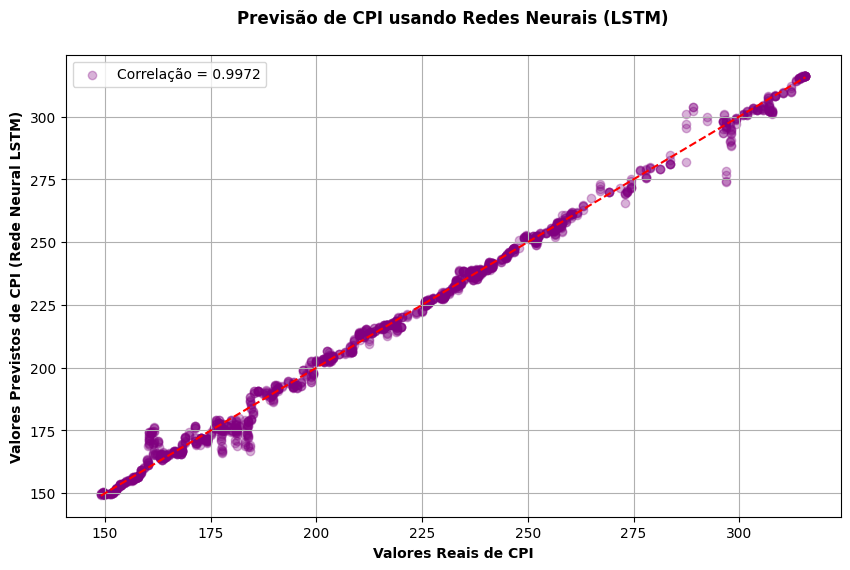

In [ ]:
# Plotando os resultados
plt.figure(figsize=(10, 6))
plt.scatter(y_test_inverse, y_pred_inverse, color='purple', alpha=0.3, label=f'Correlação = {np.round(np.corrcoef(y_test_inverse.flatten(), y_pred_inverse.flatten())[0,1], 4)}')
plt.plot([min(y_test_inverse), max(y_test_inverse)], [min(y_test_inverse), max(y_test_inverse)], 'r--')
plt.xlabel('Valores Reais de CPI', fontdict={'fontsize': 10}, weight='bold')
plt.ylabel('Valores Previstos de CPI (Rede Neural LSTM)', fontdict={'fontsize': 10}, weight='bold')
plt.title('Previsão de CPI usando Redes Neurais (LSTM)', weight='bold', y=1.05)
plt.legend() # Usar a função .legend() para exibir a label com a correlação

plt.grid(True)
plt.savefig('cpi_lstm.png')
plt.show()

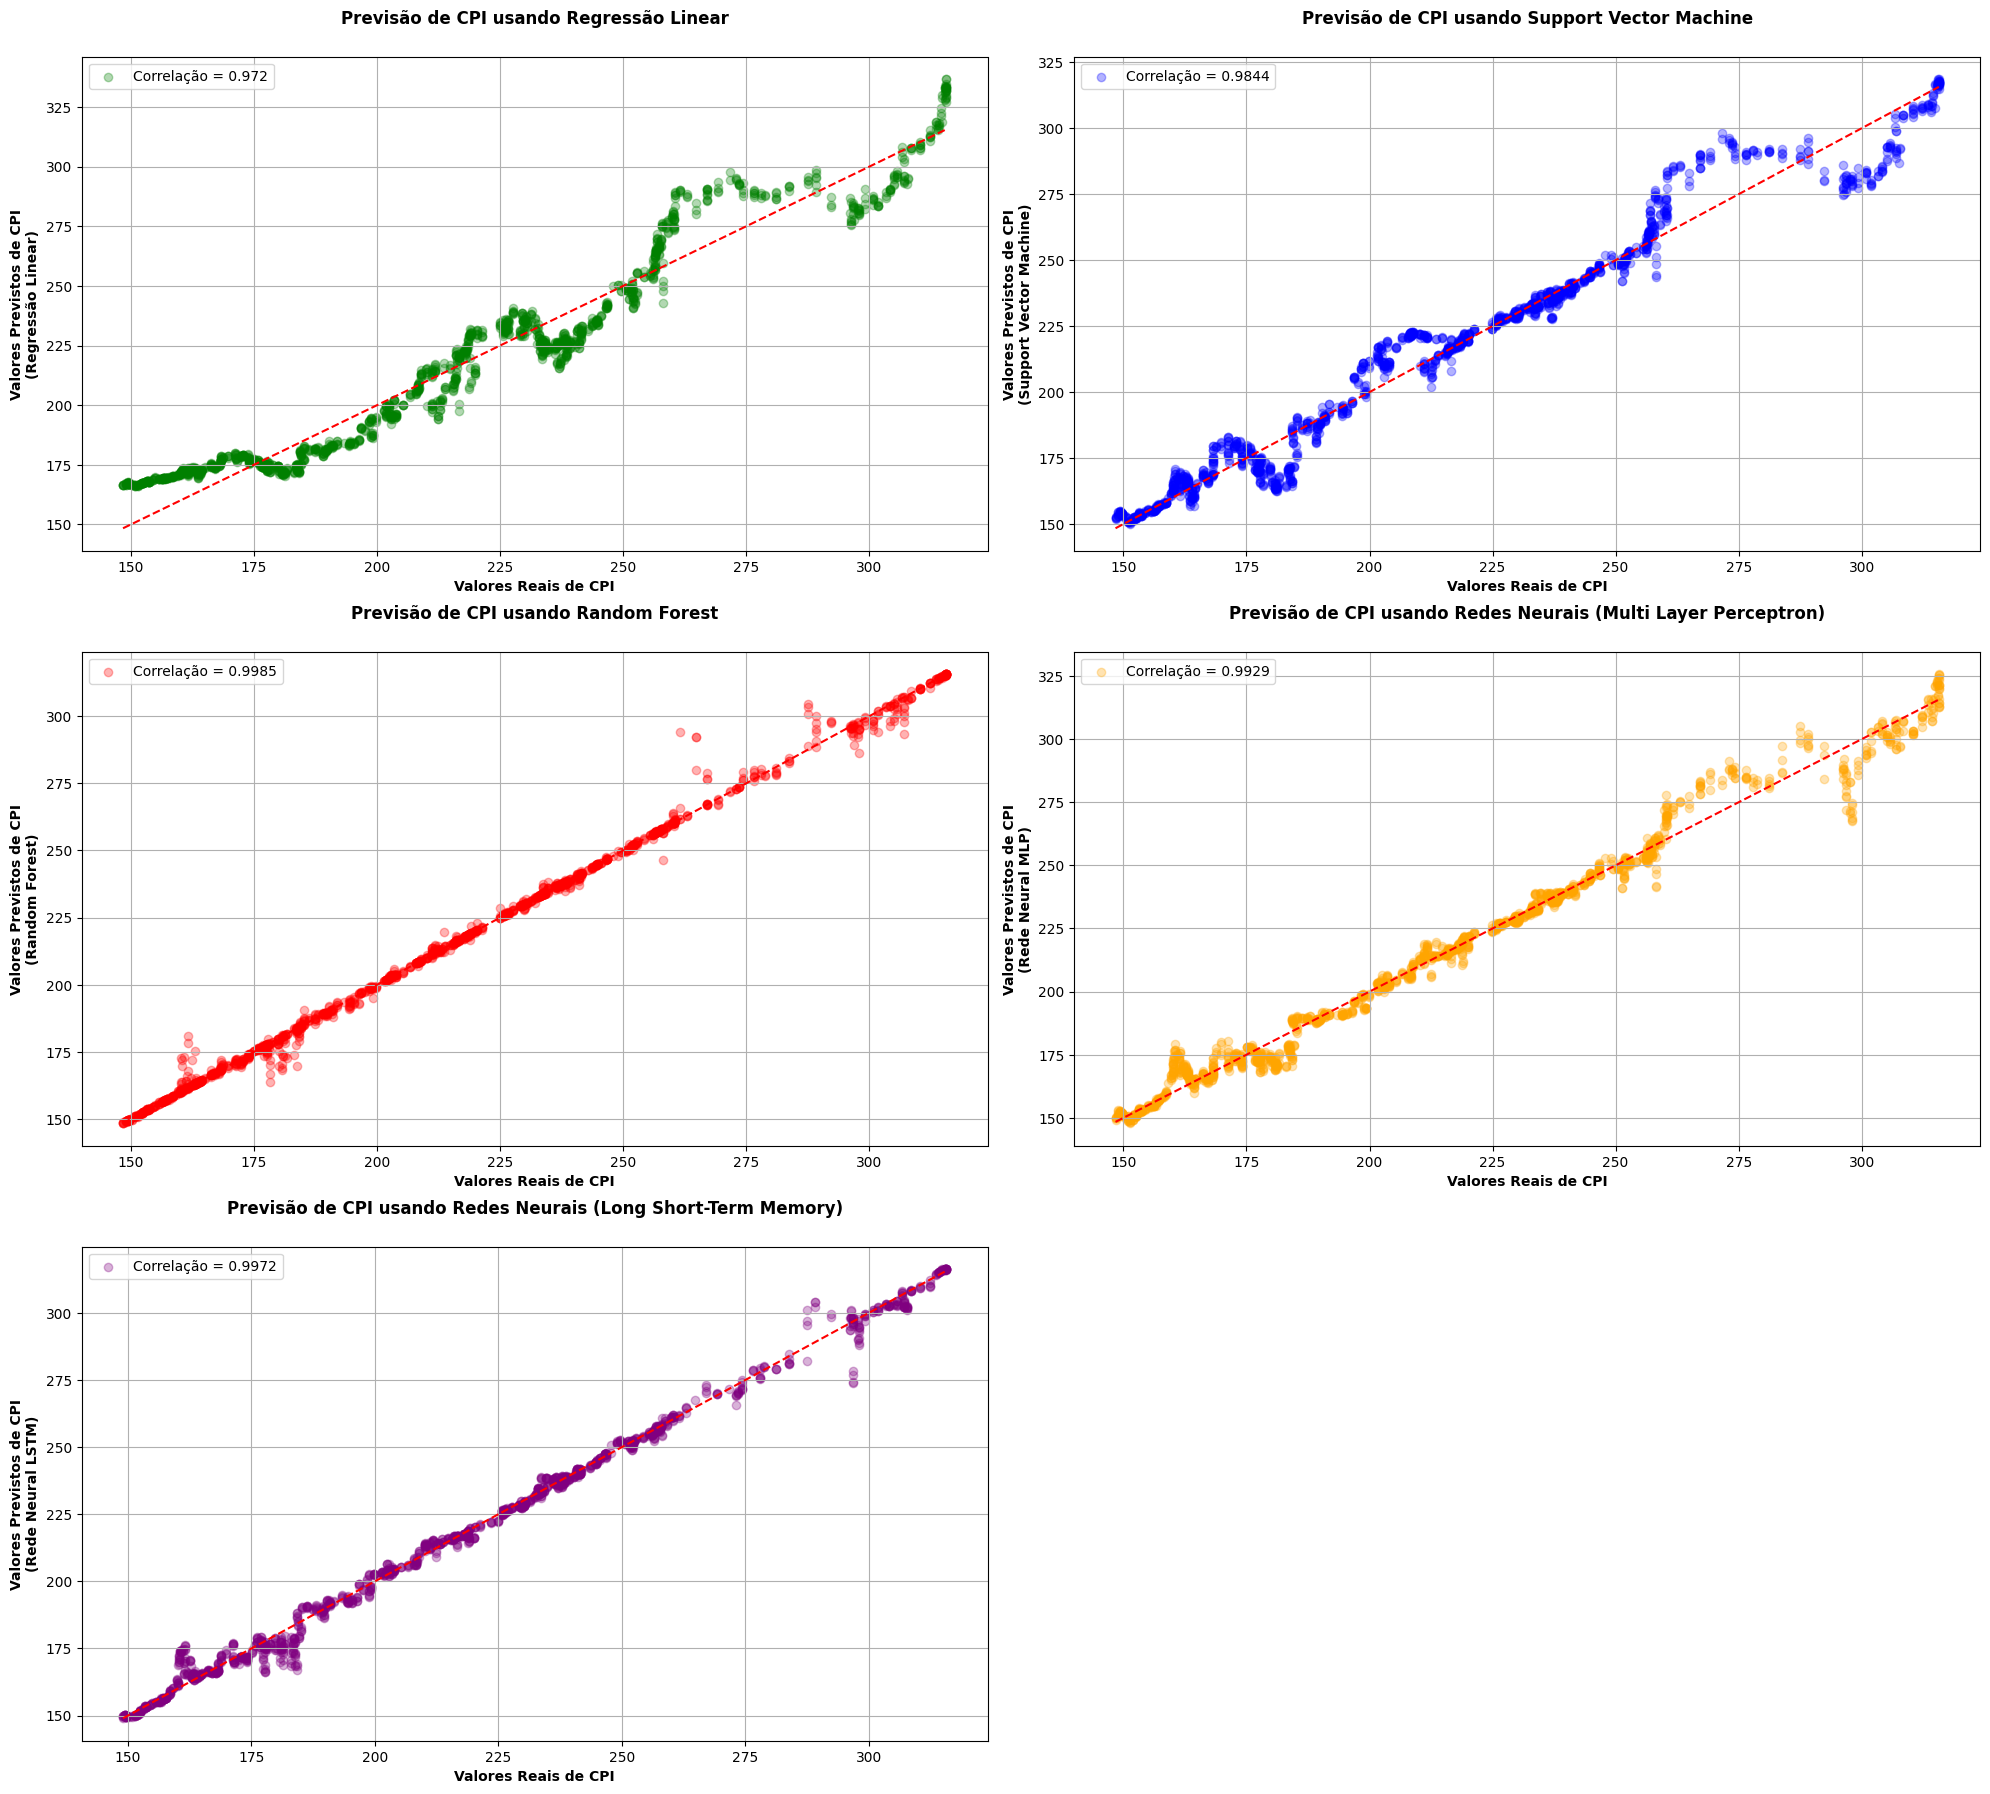

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(20, 18))

# Regressão Linear
axes[0, 0].scatter(y_test_lr, y_pred_lr, color='green', alpha=0.3, label=f'Correlação = {np.round(np.corrcoef(y_test_lr, y_pred_lr)[0,1], 4)}')
axes[0, 0].plot([min(y_test_lr), max(y_test_lr)], [min(y_test_lr), max(y_test_lr)], 'r--')
axes[0, 0].set_xlabel('Valores Reais de CPI', fontdict={'fontsize': 10}, weight='bold')
axes[0, 0].set_ylabel('Valores Previstos de CPI\n(Regressão Linear)', fontdict={'fontsize': 10}, weight='bold')
axes[0, 0].set_title('Previsão de CPI usando Regressão Linear', weight='bold', y=1.05)
axes[0, 0].grid(True)
axes[0, 0].legend()

# Support Vector Machine
axes[0, 1].scatter(y_test_svm, y_pred_svm, color='blue', alpha=0.3, label=f'Correlação = {np.round(np.corrcoef(y_test_svm, y_pred_svm)[0,1], 4)}')
axes[0, 1].plot([min(y_test_svm), max(y_test_svm)], [min(y_test_svm), max(y_test_svm)], 'r--')
axes[0, 1].set_xlabel('Valores Reais de CPI', fontdict={'fontsize': 10}, weight='bold')
axes[0, 1].set_ylabel('Valores Previstos de CPI\n(Support Vector Machine)', fontdict={'fontsize': 10}, weight='bold')
axes[0, 1].set_title('Previsão de CPI usando Support Vector Machine', weight='bold', y=1.05)
axes[0, 1].grid(True)
axes[0, 1].legend()

# Random Forest
axes[1, 0].scatter(y_test_rf, y_pred_rf, color='red', alpha=0.3, label=f'Correlação = {np.round(np.corrcoef(y_test_rf, y_pred_rf)[0,1], 4)}')
axes[1, 0].plot([min(y_test_rf), max(y_test_rf)], [min(y_test_rf), max(y_test_rf)], 'r--')
axes[1, 0].set_xlabel('Valores Reais de CPI', fontdict={'fontsize': 10}, weight='bold')
axes[1, 0].set_ylabel('Valores Previstos de CPI\n(Random Forest)', fontdict={'fontsize': 10}, weight='bold')
axes[1, 0].set_title('Previsão de CPI usando Random Forest', weight='bold', y=1.05)
axes[1, 0].grid(True)
axes[1, 0].legend()

# Multi Layer Perceptron
axes[1, 1].scatter(y_test_mlp, y_pred_mlp, color='orange', alpha=0.3, label=f'Correlação = {np.round(np.corrcoef(y_test_mlp, y_pred_mlp)[0,1], 4)}')
axes[1, 1].plot([min(y_test_mlp), max(y_test_mlp)], [min(y_test_mlp), max(y_test_mlp)], 'r--')
axes[1, 1].set_xlabel('Valores Reais de CPI', fontdict={'fontsize': 10}, weight='bold')
axes[1, 1].set_ylabel('Valores Previstos de CPI\n(Rede Neural MLP)', fontdict={'fontsize': 10}, weight='bold')
axes[1, 1].set_title('Previsão de CPI usando Redes Neurais (Multi Layer Perceptron)', weight='bold', y=1.05)
axes[1, 1].grid(True)
axes[1, 1].legend()

# Long Short-Term Memory
axes[2, 0].scatter(y_test_inverse, y_pred_inverse, color='purple', alpha=0.3, label=f'Correlação = {np.round(np.corrcoef(y_test_inverse.flatten(), y_pred_inverse.flatten())[0,1], 4)}')
axes[2, 0].plot([min(y_test_inverse), max(y_test_inverse)], [min(y_test_inverse), max(y_test_inverse)], 'r--')
axes[2, 0].set_xlabel('Valores Reais de CPI', fontdict={'fontsize': 10}, weight='bold')
axes[2, 0].set_ylabel('Valores Previstos de CPI\n(Rede Neural LSTM)', fontdict={'fontsize': 10}, weight='bold')
axes[2, 0].set_title('Previsão de CPI usando Redes Neurais (Long Short-Term Memory)', weight='bold', y=1.05)
axes[2, 0].grid(True)
axes[2, 0].legend()

axes[2, 1].remove()

plt.tight_layout()
# plt.subplots_adjust(wspace=0.1)  # Ajuste o valor de vspace aqui
plt.savefig('cpi_modelos.png')
plt.show()

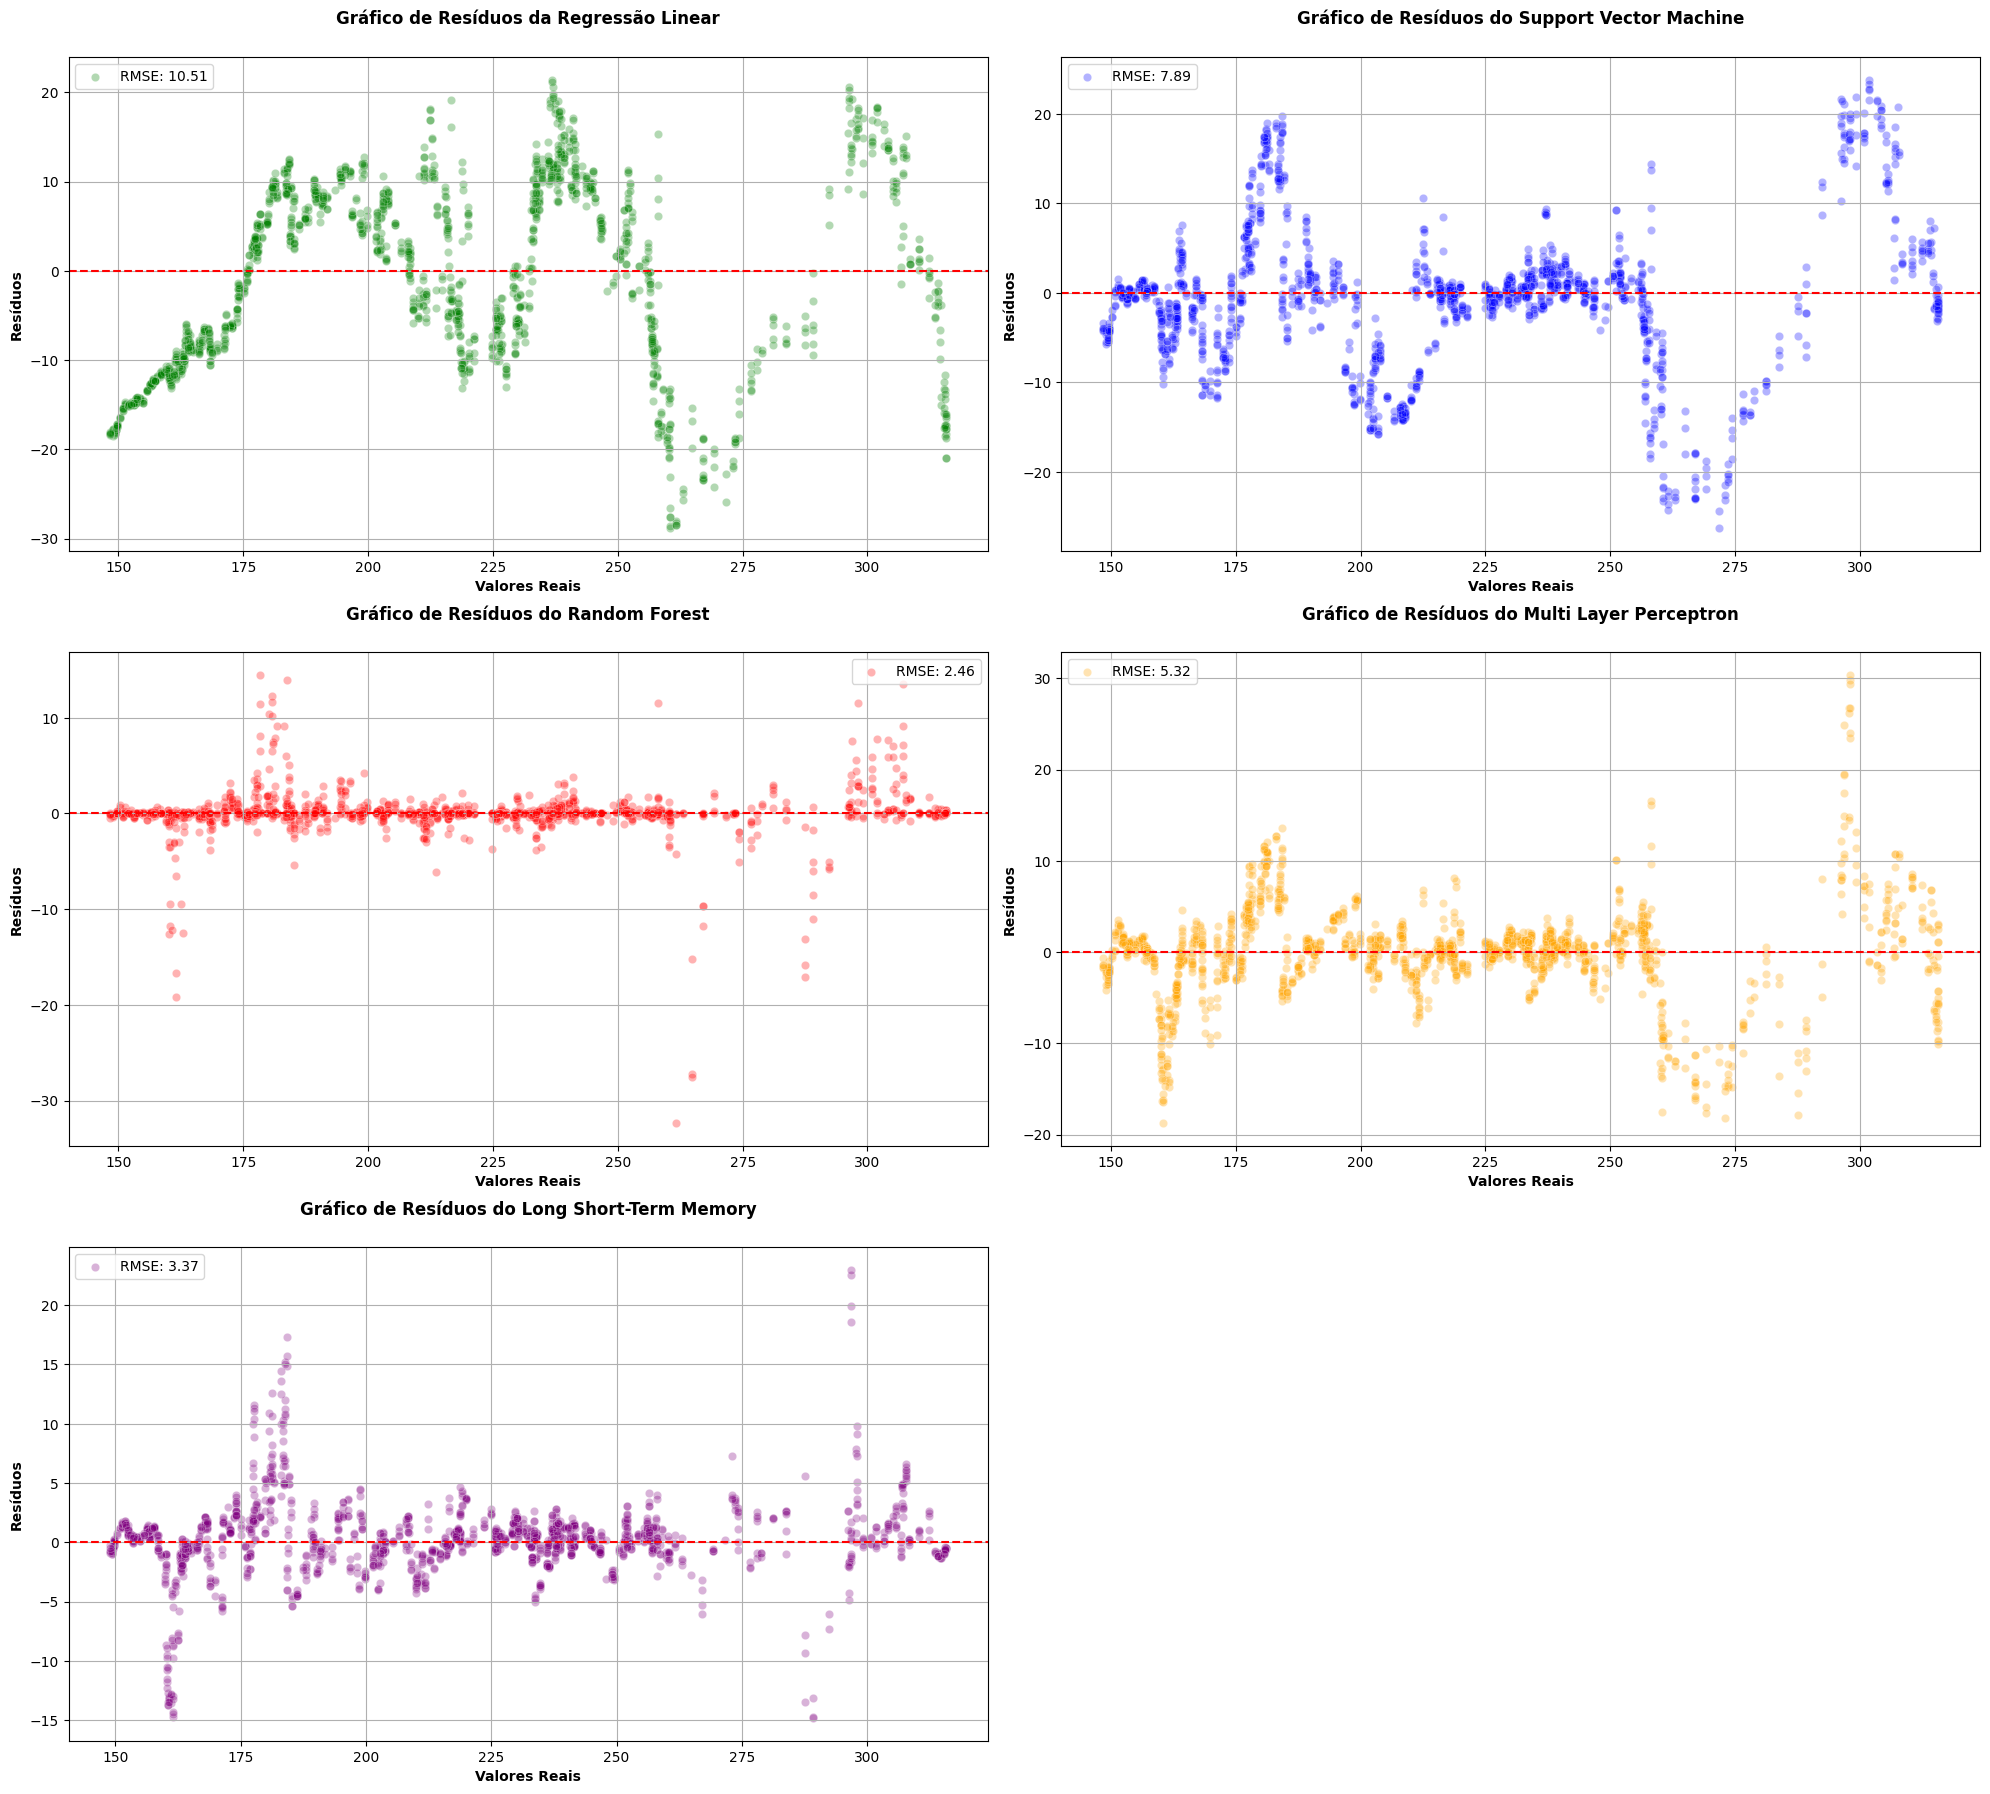

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(20, 18))

# Calculando os resíduos da Regressão Linear
residuals_lr = y_test_lr - y_pred_lr
residuals_svm = y_test_svm - y_pred_svm
residuals_rf = y_test_rf - y_pred_rf
residuals_mlp = y_test_mlp - y_pred_mlp
residuals_lstm = y_test_inverse.flatten() - y_pred_inverse.flatten()

# Gráfico de Resíduos da Regressão Linear
sns.scatterplot(x=y_test_lr, y=residuals_lr, color='green', alpha=0.3, ax=axes[0, 0], label=f'RMSE: {rmse_lr:.2f}')
axes[0, 0].axhline(y=0, color='r', linestyle='--')  # Linha de resíduo zero
axes[0, 0].set_xlabel('Valores Reais', fontdict={'fontsize': 10}, weight='bold')
axes[0, 0].set_ylabel('Resíduos', fontdict={'fontsize': 10}, weight='bold')
axes[0, 0].set_title('Gráfico de Resíduos da Regressão Linear', fontdict={'fontsize': 12}, weight='bold', y=1.05)
axes[0, 0].grid(True)

# Gráfico de Resíduos do Support Vector Machine
sns.scatterplot(x=y_test_svm, y=residuals_svm, color='blue', alpha=0.3, ax=axes[0, 1], label=f'RMSE: {rmse_svm:.2f}')
axes[0, 1].axhline(y=0, color='r', linestyle='--')  # Linha de resíduo zero
axes[0, 1].set_xlabel('Valores Reais', fontdict={'fontsize': 10}, weight='bold')
axes[0, 1].set_ylabel('Resíduos', fontdict={'fontsize': 10}, weight='bold')
axes[0, 1].set_title('Gráfico de Resíduos do Support Vector Machine', fontdict={'fontsize': 12}, weight='bold', y=1.05)
axes[0, 1].grid(True)

# Gráfico de Resíduos do Random Forest
sns.scatterplot(x=y_test_rf, y=residuals_rf, color='red', alpha=0.3, ax=axes[1, 0], label=f'RMSE: {rmse_rf:.2f}')
axes[1, 0].axhline(y=0, color='r', linestyle='--')  # Linha de resíduo zero
axes[1, 0].set_xlabel('Valores Reais', fontdict={'fontsize': 10}, weight='bold')
axes[1, 0].set_ylabel('Resíduos', fontdict={'fontsize': 10}, weight='bold')
axes[1, 0].set_title('Gráfico de Resíduos do Random Forest', fontdict={'fontsize': 12}, weight='bold', y=1.05)
axes[1, 0].grid(True)

# Gráfico de Resíduos do Multi Layer Perceptron
sns.scatterplot(x=y_test_mlp, y=residuals_mlp, color='orange', alpha=0.3, ax=axes[1, 1], label=f'RMSE: {rmse_mlp:.2f}')
axes[1, 1].axhline(y=0, color='r', linestyle='--')  # Linha de resíduo zero
axes[1, 1].set_xlabel('Valores Reais', fontdict={'fontsize': 10}, weight='bold')
axes[1, 1].set_ylabel('Resíduos', fontdict={'fontsize': 10}, weight='bold')
axes[1, 1].set_title('Gráfico de Resíduos do Multi Layer Perceptron', fontdict={'fontsize': 12}, weight='bold', y=1.05)
axes[1, 1].grid(True)

# Gráfico de Resíduos do Long Short-Term Memory
sns.scatterplot(x=y_test_inverse.flatten(), y=residuals_lstm, color='purple', alpha=0.3, ax=axes[2, 0], label=f'RMSE: {rmse_lstm:.2f}')
axes[2, 0].axhline(y=0, color='r', linestyle='--')  # Linha de resíduo zero
axes[2, 0].set_xlabel('Valores Reais', fontdict={'fontsize': 10}, weight='bold')
axes[2, 0].set_ylabel('Resíduos', fontdict={'fontsize': 10}, weight='bold')
axes[2, 0].set_title('Gráfico de Resíduos do Long Short-Term Memory', fontdict={'fontsize': 12}, weight='bold', y=1.05)
axes[2, 0].grid(True)

axes[2, 1].remove()

plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('cpi_residuals.png')
plt.show()